In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
# Load cleaned dataset
terror_df = pd.read_csv(
    "../data/processed/terrorism_cleaned.csv",
    parse_dates=["date"]
)

In [3]:
# Check missing coordinates
terror_df[["latitude", "longitude"]].isnull().sum()

latitude     4691
longitude    4692
dtype: int64

In [4]:
# Remove records with missing coordinates
geo_df = terror_df.dropna(
    subset=["latitude", "longitude"]
)

geo_df.shape

(205014, 25)

In [5]:
# Count incidents by region
top_regions = (
    geo_df["region_txt"]
    .value_counts()
)

top_regions

region_txt
Middle East & North Africa     57278
South Asia                     54214
Sub-Saharan Africa             23164
South America                  18974
Western Europe                 17171
Southeast Asia                 13964
Central America & Caribbean     9386
Eastern Europe                  5299
North America                   3841
East Asia                        839
Central Asia                     565
Australasia & Oceania            319
Name: count, dtype: int64

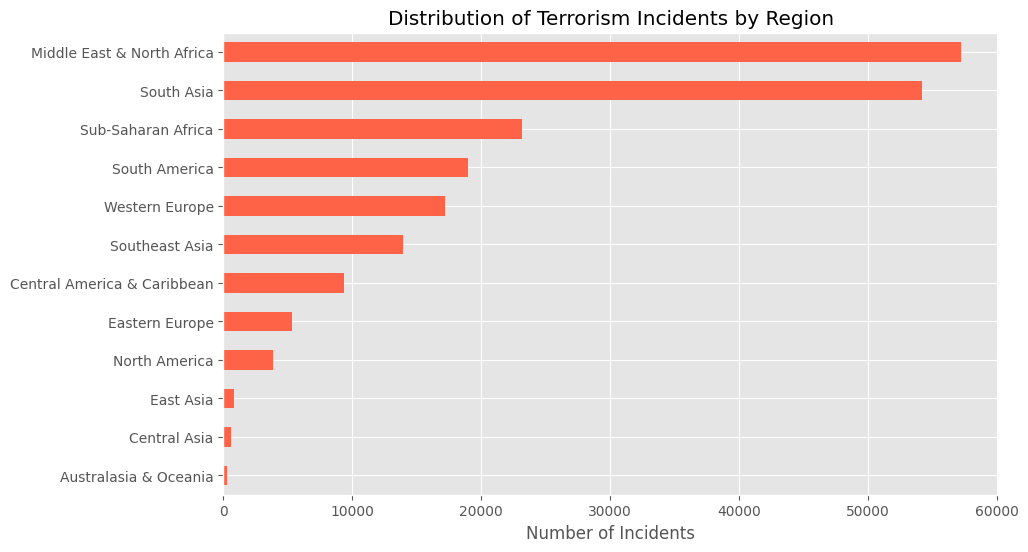

In [8]:
# Plot incidents by region
plt.figure(figsize=(10,6))

top_regions.sort_values().plot(
    kind="barh",
    color="tomato"
)

plt.xlabel("Number of Incidents")
plt.ylabel("")
plt.title("Distribution of Terrorism Incidents by Region")

plt.show()

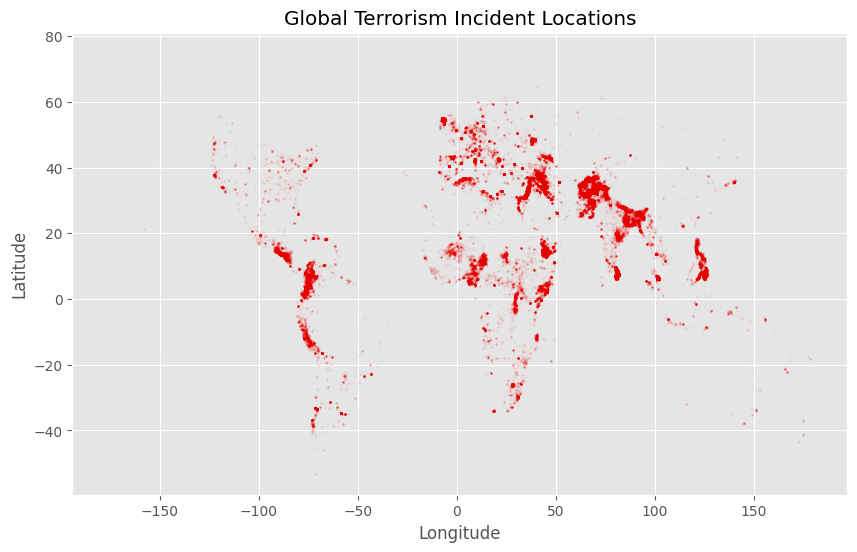

In [11]:
# Plot incident locations
plt.figure(figsize=(10,6))

plt.scatter(
    geo_df["longitude"],
    geo_df["latitude"],
    alpha=0.02,
    s=1,
    color="red"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Global Terrorism Incident Locations")

plt.show()

In [16]:
# Top cities by incident count
top_cities = (
    geo_df[geo_df["city"] != "Unknown"]["city"]
    .value_counts()
    .head(20)
)

top_cities

city
Baghdad           8020
Karachi           2723
Lima              2359
Mosul             2330
Belfast           2242
Mogadishu         1962
Santiago          1643
San Salvador      1560
Kabul             1102
Athens            1091
Istanbul          1056
Kirkuk            1022
Bogota             988
Beirut             914
Quetta             878
Benghazi           863
Medellin           853
Peshawar           847
Guatemala City     764
Baqubah            758
Name: count, dtype: int64

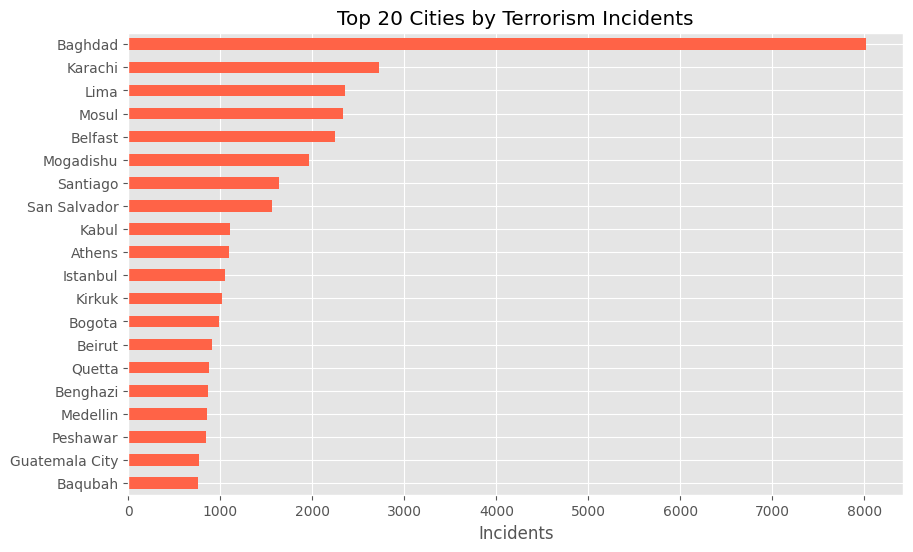

In [17]:
# Plot top cities
plt.figure(figsize=(10,6))

top_cities.sort_values().plot(
    kind="barh",
    color="tomato"
)

plt.xlabel("Incidents")
plt.ylabel("")
plt.title("Top 20 Cities by Terrorism Incidents")

plt.show()

In [18]:
# Calculate fatalities by country
country_fatalities = (
    geo_df
    .groupby("country_txt")["nkill"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

country_fatalities

country_txt
Iraq                                81240.0
Afghanistan                         67398.0
Nigeria                             29062.0
Pakistan                            25132.0
India                               19605.0
Syria                               18726.0
Sri Lanka                           15025.0
Colombia                            13947.0
Somalia                             13092.0
Yemen                               12802.0
El Salvador                         11322.0
Peru                                11313.0
Algeria                             10075.0
Philippines                          9091.0
Nicaragua                            7415.0
Democratic Republic of the Congo     7014.0
Turkey                               6321.0
Guatemala                            5036.0
Russia                               4328.0
Egypt                                4249.0
Name: nkill, dtype: float64

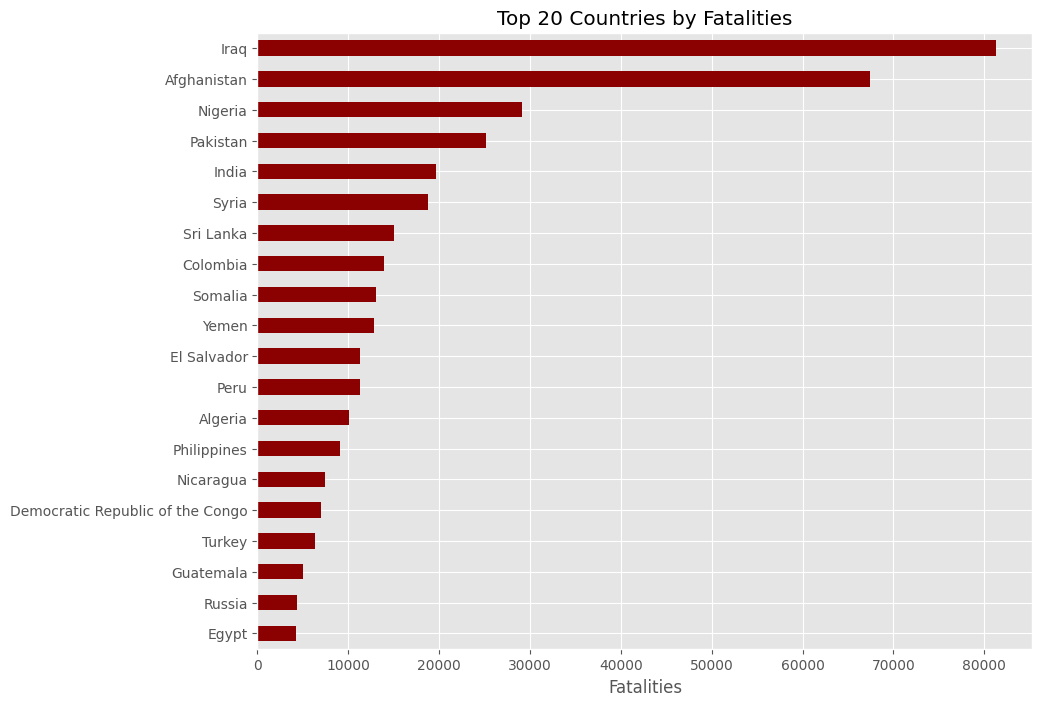

In [19]:
# Plot fatalities by country
plt.figure(figsize=(10,8))

country_fatalities.sort_values().plot(
    kind="barh",
    color="darkred"
)

plt.xlabel("Fatalities")
plt.ylabel("")
plt.title("Top 20 Countries by Fatalities")

plt.show()

In [20]:
# Filter high-casualty incidents
high_casualty_df = (
    geo_df[
        geo_df["casualties"] >= 100
    ]
)

high_casualty_df.shape

(938, 25)

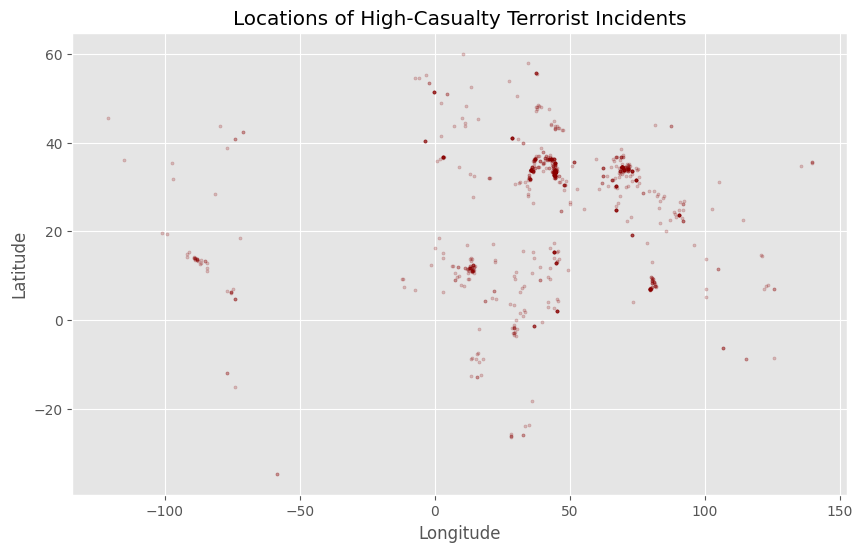

In [ ]:
# Plot high-casualty event locations
plt.figure(figsize=(10,6))

plt.scatter(
    high_casualty_df["longitude"],
    high_casualty_df["latitude"],
    alpha=0.2, 
    s=5,
    color="darkred"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Locations of High-Casualty Terrorist Incidents")

plt.show()